# 03. 모델링·평가·오류 분석

`python src/train.py`가 저장한 `results/`를 읽어 정리합니다. 이 노트북은 학습을 다시 돌리지 않습니다(전체 실행은 4코어 PC에서 약 30초).

**설계 요약**
- 학습: Batch 1 정제 41셀 / 22개 충전 정책
- Valid: 정책 평균 수명 순으로 5구간을 만들고 구간마다 정책 1개를 뽑은 Hold-out 5정책(9셀)
- Train(CV): 나머지 17정책·32셀에서 정책 단위 GroupKFold 5-fold × 5회 반복
- 후보: M0 중앙값, M1 단일 피처 선형, M2 ElasticNet, M3 Huber, M4 Gaussian Process, M5 RandomForest·LightGBM × 피처셋 F0~F2 (F3는 보조)
- 선택 규칙(사전 고정): 최저 CV MAPE + 표준오차 안에서 피처 수 → 모델 복잡도 순으로 가장 단순한 후보
- 고정 모델(Development 32셀 학습)로 Hold-out, Batch 2, Batch 3를 한 번씩 평가

In [1]:
import sys, json, warnings
from pathlib import Path
ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
sys.path.insert(0, str(ROOT / 'src'))
warnings.filterwarnings('ignore')
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy.stats import spearmanr
plt.rcParams.update({'axes.spines.top': False, 'axes.spines.right': False, 'axes.grid': True,
                     'grid.color': '#e6e6e6', 'font.size': 10, 'figure.dpi': 110})
pd.set_option('display.width', 160); pd.set_option('display.max_columns', 30)
C = {'Batch 1': '#1F4E79', 'Batch 2': '#D9822B', 'Batch 3': '#2E8B74'}
B = ['Batch 1', 'Batch 2', 'Batch 3']
R = ROOT / 'results'
from IPython.display import Image, display
run = json.loads((R / 'run_summary.json').read_text())
print(json.dumps(run['split'], ensure_ascii=False, indent=1))
print('selected:', run['selected']['id'], '|', run['selected']['params'], '| CV MAPE %.2f ± SE %.2f' % (run['selected']['cv_mean'], run['selected']['cv_se']))
print('standardized coefficients (log10 life):', run['coefficients_standardized'])

{
 "holdout_policies": [
  "4.4C(80%)-4.4C",
  "5.4C(80%)-5.4C",
  "6C(40%)-3.6C",
  "6C(40%)-3C",
  "6C(60%)-3C"
 ],
 "n_dev_cells": 32,
 "n_dev_policies": 17,
 "n_holdout_cells": 9,
 "holdout_cells": [
  "b1c005",
  "b1c020",
  "b1c021",
  "b1c024",
  "b1c025",
  "b1c026",
  "b1c027",
  "b1c032",
  "b1c033"
 ],
 "n_test_b2": 39,
 "n_test_b3": 40,
 "n_cv_folds": 25,
 "seed": 42
}
selected: M2_ElasticNet_F1_capacity_039 | alpha=0.001, l1_ratio=0.9 | CV MAPE 7.33 ± SE 0.48
standardized coefficients (log10 life): {'dq_logvar': -0.15738, 'qd_mean': 0.03238, 'qd_slope': -0.01584, 'intercept': 2.94692}


## 1. 후보 비교 (Batch 1 CV)

,id,params,n_features,cv_mean,cv_std,cv_se
0,M2_ElasticNet_F1_capacity_039,"alpha=0.001, l1_ratio=0.9",3,7.3281,2.4238,0.4848
1,M2_ElasticNet_F1_capacity_040,"alpha=0.003, l1_ratio=0.1",3,7.3305,2.3870,0.4774
2,M2_ElasticNet_F1_capacity_038,"alpha=0.001, l1_ratio=0.5",3,7.3320,2.3958,0.4792
3,M2_ElasticNet_F1_capacity_036,"alpha=0.0003, l1_ratio=0.9",3,7.3413,2.3815,0.4763
4,M2_ElasticNet_F1_capacity_043,"alpha=0.01, l1_ratio=0.1",3,7.3416,2.4462,0.4892
5,M2_ElasticNet_F1_capacity_041,"alpha=0.003, l1_ratio=0.5",3,7.3417,2.4738,0.4948
6,M2_ElasticNet_F1_capacity_037,"alpha=0.001, l1_ratio=0.1",3,7.3445,2.3740,0.4748
7,M2_ElasticNet_F1_capacity_035,"alpha=0.0003, l1_ratio=0.5",3,7.3455,2.3758,0.4752
8,M2_ElasticNet_F1_capacity_034,"alpha=0.0003, l1_ratio=0.1",3,7.3498,2.3710,0.4742
9,M2_ElasticNet_F1_capacity_042,"alpha=0.003, l1_ratio=0.9",3,7.4191,2.6205,0.5241


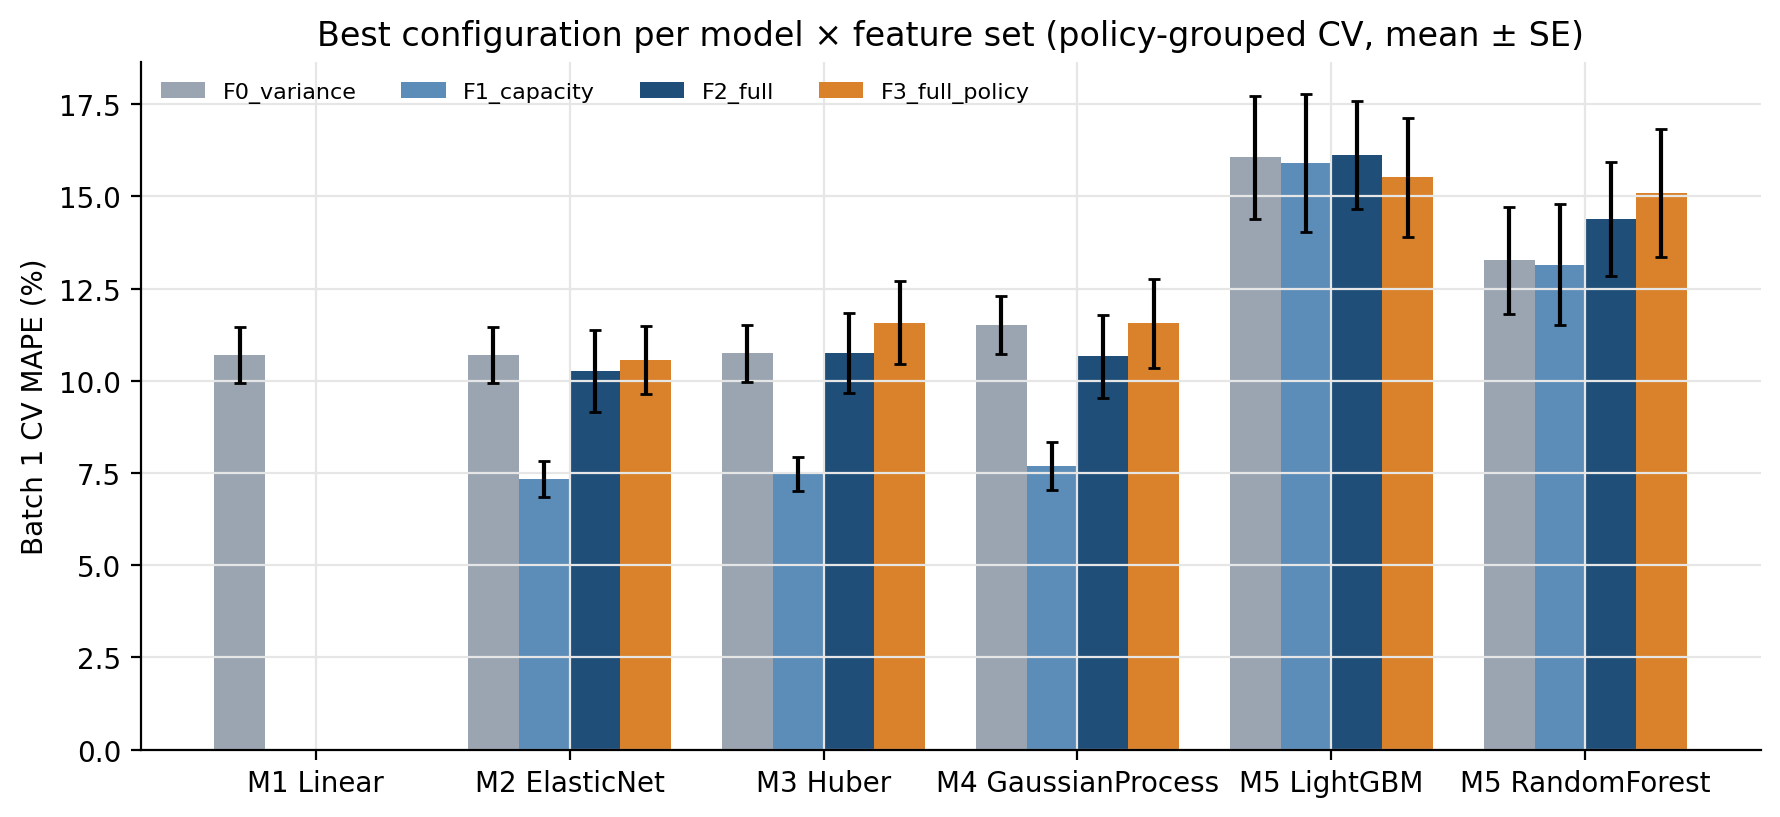

feature_set,F0_variance,F1_capacity,F2_full,F3_full_policy
label,,,,
M1 Linear,10.70,NaN,NaN,NaN
M2 ElasticNet,10.70,7.33,10.26,10.57
M3 Huber,10.74,7.48,10.75,11.58
M4 GaussianProcess,11.51,7.68,10.67,11.56
M5 LightGBM,16.06,15.91,16.13,15.52
M5 RandomForest,13.27,13.15,14.40,15.09


In [2]:
cv = pd.read_csv(R / 'cv_results.csv')
display(cv.head(10)[['id', 'params', 'n_features', 'cv_mean', 'cv_std', 'cv_se']])
display(Image(R / 'figures/cv_comparison.png'))
pd.read_csv(R / 'feature_set_ablation.csv').pivot(index='label', columns='feature_set', values='cv_mean').round(2)

- ElasticNet·Huber·GP 모두 F1(ΔQ + 초기 용량 평균·기울기)에서 가장 좋고(7.3~7.7%), F0 단일 피처(10.7%)보다 3%p 낮습니다.
- 저항·온도를 더한 F2와 정책을 더한 F3는 오히려 나빠집니다. 정책 단위 CV에서 새 정책에 일반화되지 않는 정보라는 뜻입니다.
- 트리 계열(RF 13.1%, LightGBM 15.9%)은 32셀 소표본에서 가장 나쁩니다.
- 1-SE 규칙으로 **M2 ElasticNet + F1** (alpha=0.001, l1_ratio=0.9)이 선택되었습니다.

## 2. 성능 결과 (과제 Reporting format)

In [3]:
perf = pd.read_csv(R / 'model_performance.csv'); display(perf)
pd.read_csv(R / 'metrics_detail.csv')

,구분,MAPE (%),비고
0,Train (Batch 1 CV),7.33,정책 단위 GroupKFold 5-fold × 5회 검증 fold 평균 (표준편차 ...
1,Valid (Batch 1 Hold-out),8.44,학습에 쓰지 않은 B1 충전 정책 5개
2,Test (Batch 2),35.30,최종 필수 평가
3,Gap (Train-Valid),1.11,"Valid − Train, (+) : 과적합 의심"
4,Gap (Valid-Test),26.86,"Test − Valid, (+) : 배치간 일반화 저하 의심"
5,Gap (Target-Test),26.20,"Test − 9.1, Target : 원논문 9.1%"
6,Test (Batch 3),9.87,추가 평가 (선택)
7,Gap (Batch2-Batch3),-25.43,"Batch 3 − Batch 2, Test 성능 간 비교"
8,"Gap (Target-Test), Batch 3",0.77,"Batch 3 − 9.1, 원논문 성능 비교"


,set,group,n,MAPE,MAE,RMSE,bias_pct,over_share,MAPE_CI95_low,MAPE_CI95_high,spearman,log10_offset
0,Batch 2,all,39,35.297,210.330,269.973,35.297,100.000,29.590,41.158,0.842,0.128
1,Batch 3,all,40,9.868,120.141,199.730,-4.752,45.000,7.336,12.682,0.836,-0.025
2,Valid,all,9,8.436,63.587,80.859,2.172,44.444,4.519,12.571,0.917,0.007
3,Batch 2,structure=new,9,50.496,448.352,493.420,50.496,100.000,NaN,NaN,0.233,0.171
4,Batch 2,structure=standard,30,30.737,138.923,147.350,30.737,100.000,NaN,NaN,0.674,0.115
5,Batch 2,life_in_train_range=False,30,30.737,138.923,147.350,30.737,100.000,NaN,NaN,0.674,0.115
6,Batch 2,life_in_train_range=True,9,50.496,448.352,493.420,50.496,100.000,NaN,NaN,0.233,0.171


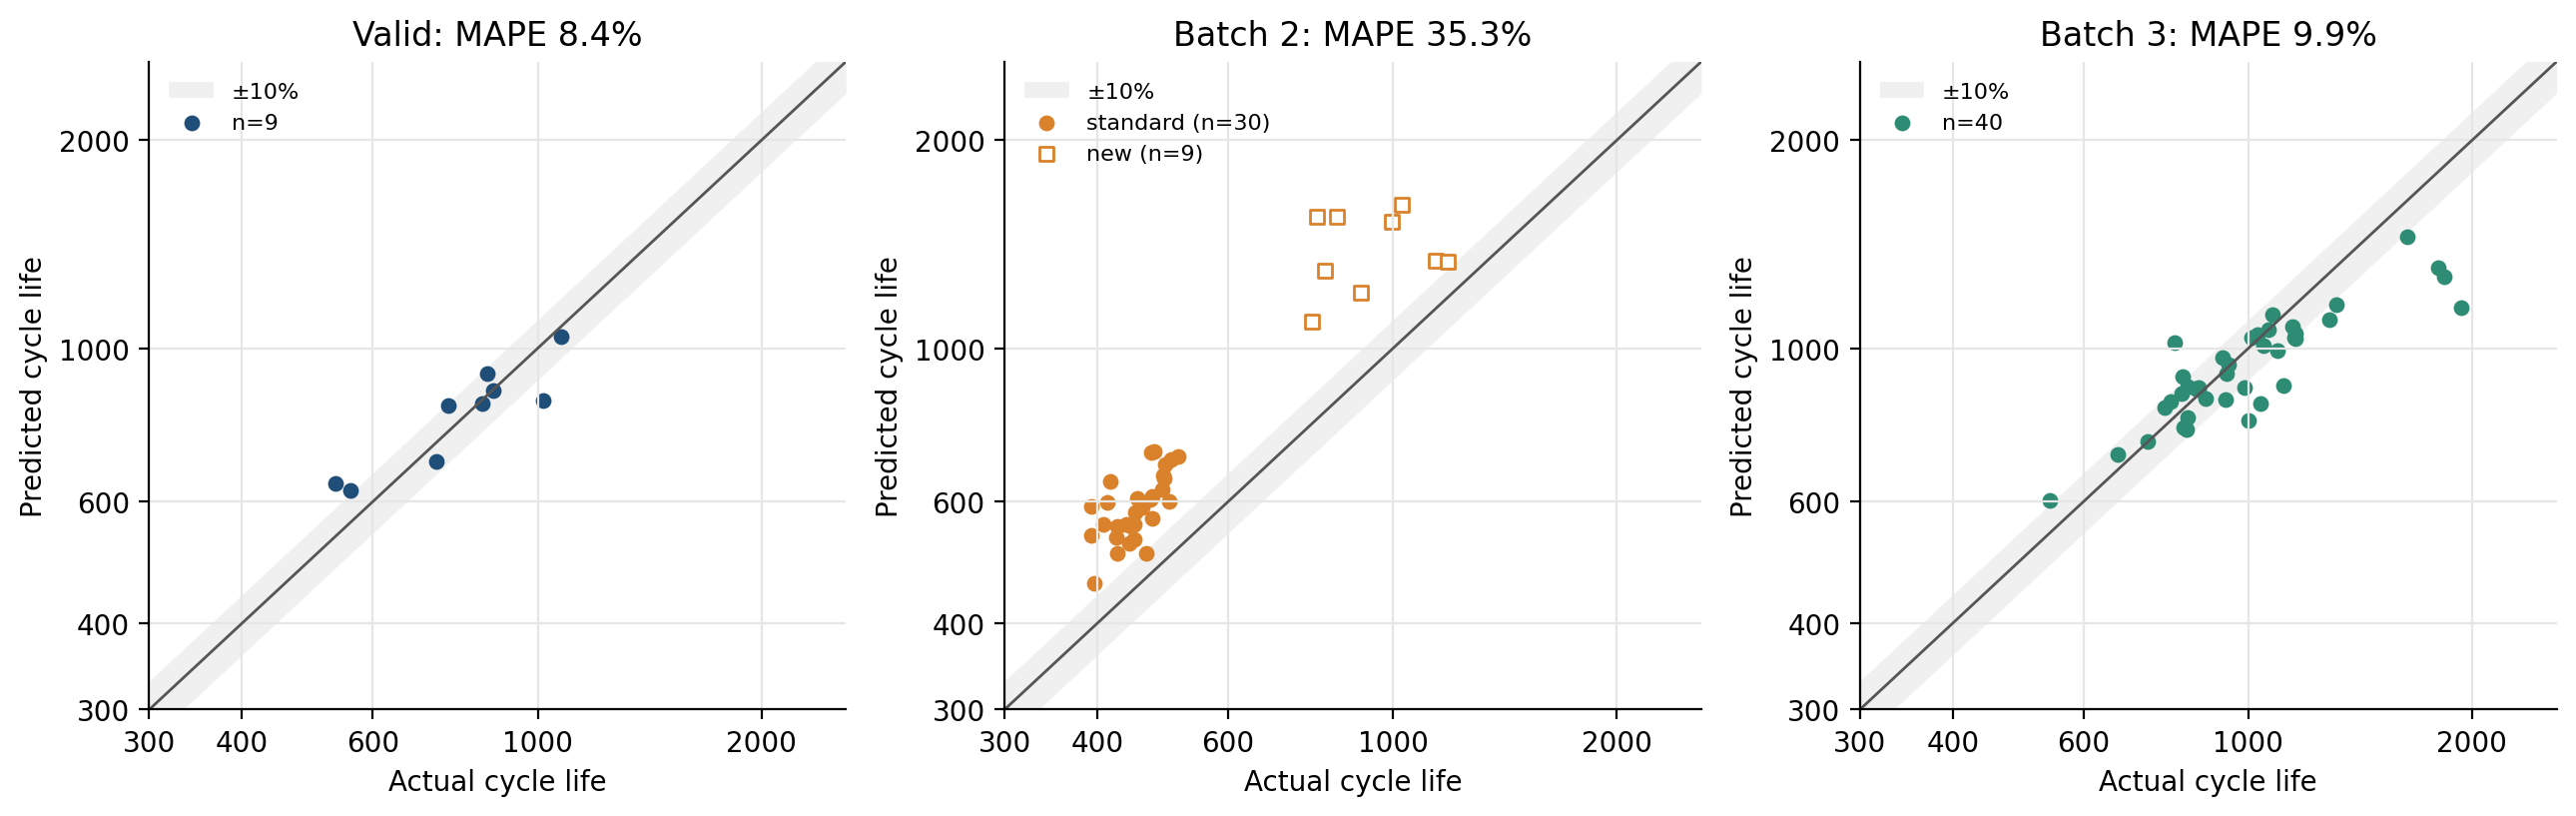

In [4]:
display(Image(R / 'figures/pred_vs_actual.png'))

**Gap 해석**
- Gap(Train−Valid) +1.1%p: Hold-out 정책 5개에서도 CV와 비슷해, Batch 1 안에서는 과적합 신호가 약합니다.
- Gap(Valid−Test) +26.9%p: Batch 2에서 성능이 크게 떨어집니다. Batch 2 39셀이 **모두 과대예측**(평균 +35%)되었습니다.
- Gap(Target−Test) +26.2%p: 원논문 9.1%보다 높습니다. 단, 원논문 테스트셋(2017-06-30)과 과제 Batch 2(2018-02-20)는 다른 배치이므로 같은 조건 비교가 아닙니다.
- Batch 3는 9.9%로 원논문 목표와 0.8%p 차이입니다. Gap(Batch2−Batch3) −25.4%p로, Batch 2만 유독 어려운 배치입니다.

## 3. 오류 분석

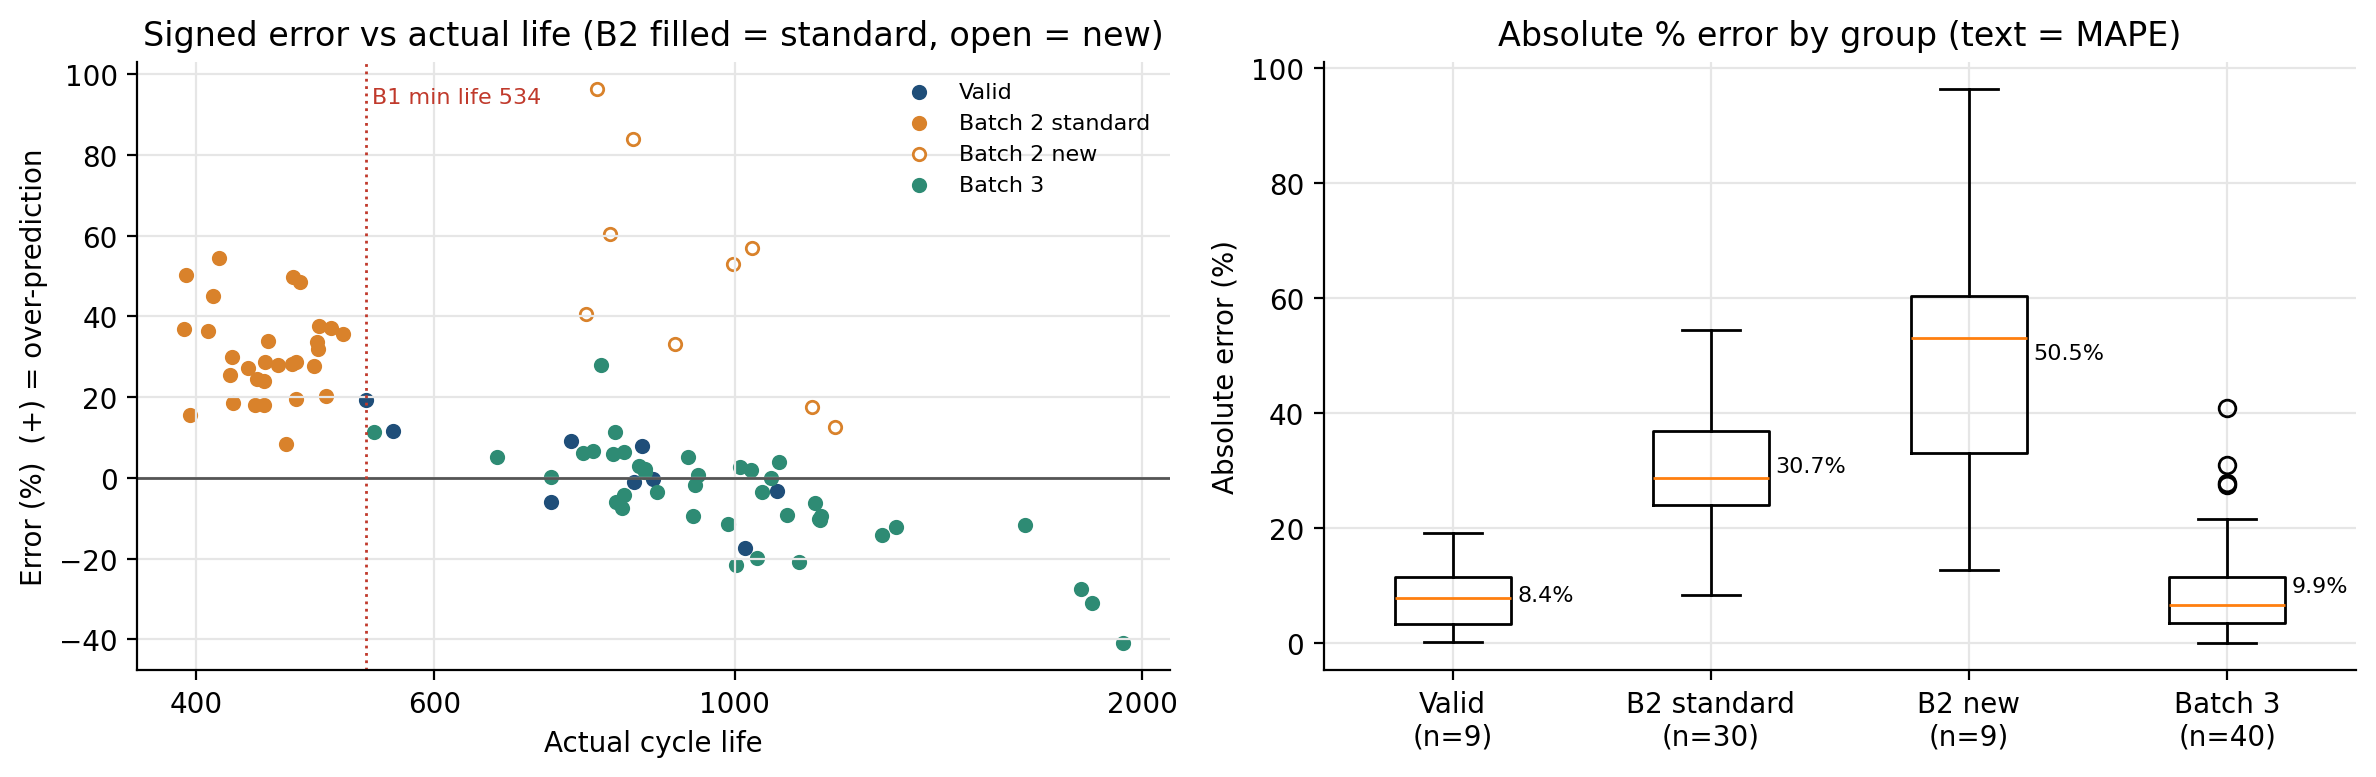

,set,cell_uid,policy,structure,dq_logvar,y_true,y_pred,pct_err,life_in_train_range,feature_in_train_range
0,Batch 2,b2c009,5.6C(26%)-4.5C-newstructure,new,-4.34,791.0,1552.21,96.23,True,True
1,Batch 2,b2c044,5.2C(58%)-4C-newstructure,new,-4.36,841.0,1547.86,84.05,True,True
2,Batch 2,b2c032,4.8C(80%)-4.8C-newstructure,new,-4.13,809.0,1297.08,60.33,True,True
3,Batch 2,b2c043,4.8C(80%)-4.8C-newstructure,new,-4.27,1029.0,1614.22,56.87,True,True
4,Batch 2,b2c005,3.6C(30%)-6C,standard,-3.09,416.0,642.06,54.34,False,False
5,Batch 3,b3c038,5C(67%)-4C-newstructure,new,-4.34,1935.0,1144.44,-40.86,True,True
6,Batch 3,b3c007,4.8C(80%)-4.8C-newstructure,new,-4.49,1836.0,1268.04,-30.93,True,True
7,Batch 3,b3c040,5.6C(19%)-4.6C-newstructure,new,-4.30,796.0,1017.85,27.87,True,True
8,Batch 3,b3c045,4.8C(80%)-4.8C-newstructure,new,-4.52,1801.0,1306.50,-27.46,True,True
9,Batch 3,b3c022,5.9C(60%)-3.1C-newstructure,new,-4.05,1002.0,786.57,-21.50,True,True


In [5]:
display(Image(R / 'figures/error_by_group.png'))
pd.read_csv(R / 'worst_cells.csv')[['set', 'cell_uid', 'policy', 'structure', 'dq_logvar', 'y_true', 'y_pred', 'pct_err', 'life_in_train_range', 'feature_in_train_range']]

**가장 크게 틀린 셀의 공통점**
1. **Batch 2 전체의 일정한 과대예측**: 오차가 무작위가 아니라 배치 전체가 한쪽으로 밀려 있습니다(log10 오프셋 +0.13 = 약 1.34배). 배치 안 순위는 유지됩니다(Spearman 0.84).
   같은 ΔQ 분산이라도 Batch 2 셀은 Batch 1보다 일찍 EOL에 도달한다는 뜻입니다.
2. **Batch 2 new structure 셀이 최악**(MAPE 50%): ΔQ는 Batch 1 장수명 셀처럼 건강해 보이는데(학습 범위 안) 실제로는 800사이클 전후에 끝납니다.
   여기에 Batch 2의 초기 용량이 학습 범위보다 높아(39셀 중 20셀 범위 밖) 양(+)의 계수를 가진 `qd_mean`이 예측을 더 끌어올립니다. EDA Q5의 허위 상관이 실제 오차로 나타난 경우입니다.
3. **Batch 3 최장수명 셀(1,800사이클 이상) 과소예측**: 학습에 이런 긴 셀이 적어 예측이 평균 쪽으로 당겨집니다.
4. **Hold-out 최단수명 2셀(534·559) 과대예측**: 학습 범위보다 짧은 셀이라 외삽 구간입니다.

## 4. 민감도·보조 결과

In [6]:
print('라벨 버전별(선택한 설정 고정)'); display(pd.read_csv(R / 'sensitivity_labels.csv'))
print('Batch 1 전체 41셀로 재학습한 경우'); display(pd.read_csv(R / 'refit_b1_all.csv'))
print('참고: 모델 패밀리별 CV 최고 설정의 테스트 성능 (선택에는 쓰지 않음)'); display(pd.read_csv(R / 'reference_by_family.csv'))

라벨 버전별(선택한 설정 고정)


,variant,n_B1,n_dev,n_B3,cv_mean,Valid MAPE,Batch 2 MAPE,Batch 3 MAPE
0,paper_rules,41,32,40,7.33,8.44,35.30,9.87
1,provided_labels,46,37,44,9.83,7.20,53.63,19.34
2,exclude_10,36,27,40,6.64,8.93,35.38,10.82


Batch 1 전체 41셀로 재학습한 경우


,trained_on,set,n,MAPE,MAE,RMSE,bias_pct,over_share
0,Batch 1 all (41),Batch 2,39,38.648,215.121,257.451,38.648,100.0
1,Batch 1 all (41),Batch 3,40,10.435,125.605,202.953,-6.399,35.0


참고: 모델 패밀리별 CV 최고 설정의 테스트 성능 (선택에는 쓰지 않음)


,family,model,feature_set,params,cv_mean,Valid MAPE,Batch 2 MAPE,Batch 3 MAPE
0,M0,Median,F0_variance,NaN,24.61,19.59,66.48,19.77
1,M1,Linear,F0_variance,NaN,10.70,6.50,24.73,12.94
2,M2,ElasticNet,F1_capacity,"alpha=0.001, l1_ratio=0.9",7.33,8.44,35.30,9.87
3,M3,Huber,F1_capacity,"epsilon=1.75, alpha=0.0001",7.48,8.64,35.78,9.99
4,M4,GaussianProcess,F1_capacity,linear+RBF+noise,7.68,8.83,35.23,10.03
5,M5,RandomForest,F1_capacity,"max_depth=None, min_leaf=2",13.15,9.73,39.98,15.51


- 제공 라벨을 그대로 쓰면 이어측정 5셀의 라벨이 실제보다 짧아 CV 9.8%, Batch 2 53.6%, Batch 3 19.3%로 모두 나빠집니다. 원논문 규칙 정제가 성능에 실제로 중요합니다.
- 10셀을 모두 빼도(36셀) Batch 2는 35.4%로 같아, Batch 2 오차는 라벨 처리 때문이 아닙니다.
- 참고 표에서 단일 피처 선형(M1)은 Batch 2에서 24.7%로 선택 모델보다 낫습니다. 다만 이는 테스트 정답을 본 뒤의 비교이므로 모델 선택에 쓰지 않았고, 개선 방향의 근거로만 씁니다.

## 5. 사후 분석(탐색): 새 배치 소수 셀로 오프셋 보정

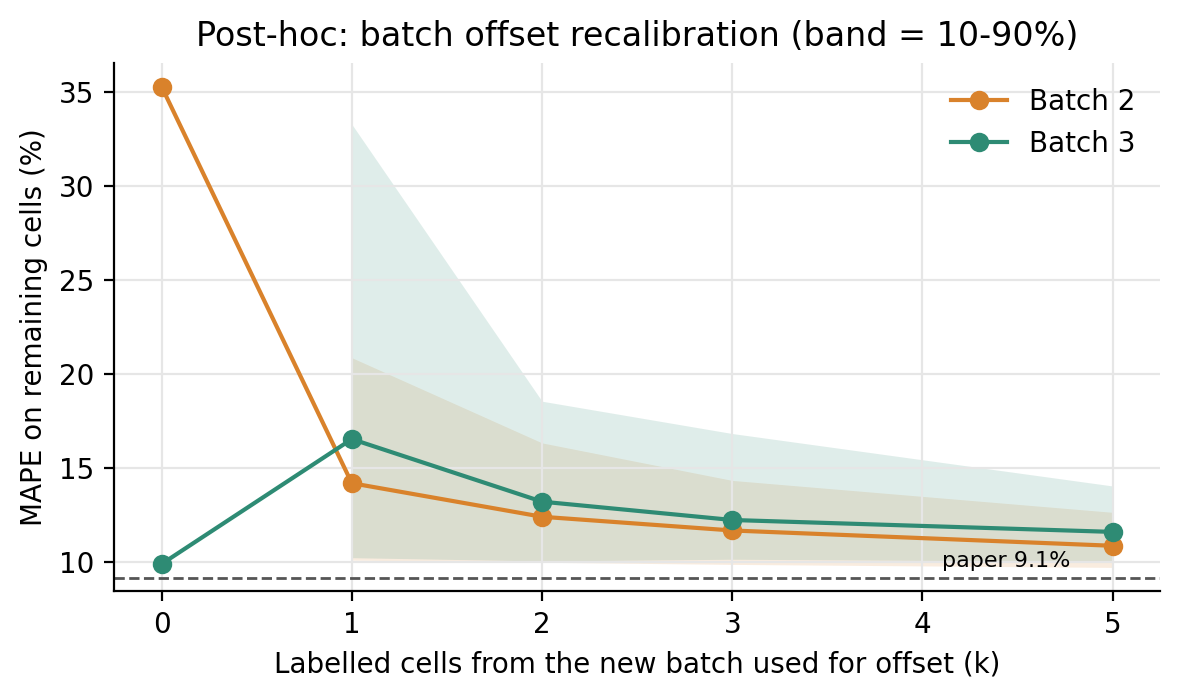

,set,k,MAPE_mean,MAPE_p10,MAPE_p90
0,Batch 2,0,35.30,NaN,NaN
1,Batch 2,1,14.17,10.07,20.86
2,Batch 2,2,12.38,9.96,16.32
3,Batch 2,3,11.65,9.85,14.32
4,Batch 2,5,10.84,9.69,12.62
5,Batch 3,0,9.87,NaN,NaN
6,Batch 3,1,16.52,10.20,33.29
7,Batch 3,2,13.19,10.03,18.54
8,Batch 3,3,12.21,10.12,16.82
9,Batch 3,5,11.58,10.00,14.02


In [7]:
display(Image(R / 'figures/posthoc_recalibration.png'))
pd.read_csv(R / 'posthoc_recalibration.csv')

Batch 2의 오차가 배치 오프셋이라면, 새 배치에서 몇 개 셀의 실제 수명만 알아도 보정할 수 있습니다.
Batch 2 셀 3개의 수명으로 log 오프셋을 추정해 나머지 36셀을 보정하면 MAPE가 35.3% → 약 11.7%, 5개면 약 10.8%로 내려갑니다.
반대로 오프셋이 없던 Batch 3에 같은 보정을 하면 오히려 나빠지므로, 보정은 입력 분포 이탈이나 초기 검증 셀로 배치 차이가 확인될 때만 적용해야 합니다.
테스트 정답을 사용한 사후 분석이므로 공식 성능 수치로 쓰지 않습니다.

## 6. 원인 가설과 개선 방향

| 관찰 | 원인 가설 | 개선 방향 |
|---|---|---|
| B2 전체 과대예측, 순위는 유지 | 실험 시기·셀 lot·측정 조건 차이로 같은 ΔQ에서 수명이 짧음 | 새 배치 초기 셀 몇 개로 오프셋 보정, 배치 정보를 함께 학습할 다배치 데이터 확보 |
| `qd_mean`이 B2에서 범위 밖 | 절대 용량 수준은 lot·보정 상태에 따라 달라짐 | 절대 용량 대신 상대 변화 피처, 입력 범위 이탈 시 단순 모델(F0)로 전환하는 규칙 |
| 최장수명 셀 과소예측 | 학습에 2,000사이클급 셀이 적음 | 장수명 셀 추가 확보, 예측 구간(GP) 함께 보고 |